# 04 - Baseline Models under Time-Aware Evaluation (no tuning)

**Goal:** compare the seven classical models of the project on equal terms, using the leakage-safe framework of notebook 02,
and see which ones suffer least from sensor drift. **Every model keeps scikit-learn's default settings** (`random_state=42`);
nothing is tuned in this preliminary phase.

> **Beginner note - the seven models in one line each**
> | Model | Idea |
> |---|---|
> | **kNN** | classify a sample like the majority of its 5 closest training samples |
> | **SVM** (RBF) | draw the widest possible curved boundary between gases |
> | **Decision Tree** | a flowchart of yes/no questions on features, grown until it fits the training data |
> | **Random Forest** | 100 such trees on random subsets of data/features, voting together |
> | **Naive Bayes** (Gaussian) | per gas, model each feature as a bell curve and assume features are independent |
> | **AdaBoost** | 50 very small trees trained one after another, each focusing on previous mistakes |
> | **Gradient Boosting** | 100 small trees added one by one, each correcting the current errors |
>
> **Majority class** is not a real model: it always predicts the most common gas of the training data. It is the "no skill" floor
> every model must beat.

**Feature pipelines** (all fitted on training batches only): `raw` = scaling only (128 features), `PCA` = scaling + PCA keeping 95% variance,
`LDA` = scaling + LDA with 5 axes. **Protocols:** P1 train B1-3, P2 train B1, P3 rolling (see notebook 02).
**Main metric: macro-F1** (every gas counts equally).

In [1]:
import os, sys, time, warnings
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "16"); warnings.filterwarnings("ignore")
from pathlib import Path
ROOT = Path.cwd().parent; sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from src.data import load_all
from src.models import default_models, reference_model
from src.evaluate import evaluate_grid, summarize
from src.plotting import apply_style, INK, INK2, GRID, SERIES, MARKERS, SEQ
apply_style()
FIG = ROOT / "results" / "figures"; RES = ROOT / "results"
X, y, batch = load_all()
models = default_models()
for n, m in models.items(): print(f"{n:18s} {m}")

kNN                KNeighborsClassifier()
SVM                SVC()
Decision Tree      DecisionTreeClassifier(random_state=42)
Random Forest      RandomForestClassifier(random_state=42)
Naive Bayes        GaussianNB()
AdaBoost           AdaBoostClassifier(random_state=42)
Gradient Boosting  GradientBoostingClassifier(random_state=42)


## 1. Run everything

7 models x 3 feature pipelines x 3 protocols = 63 runs (each run trains one model per test batch), plus the majority-class floor.
Runs are independent and deterministic, so they are executed in parallel; this only saves time and does not change any result.

In [2]:
CACHE = RES / "04_baselines_results.csv"
RERUN = False        # set True to recompute everything (about 28 minutes on 16 CPU cores)
if CACHE.exists() and not RERUN:
    res_all = pd.read_csv(CACHE)
    print(f"loaded saved results ({len(res_all)} rows); original run took {int(open(RES / '04_runtime_seconds.txt').read())} s")
else:
    t0 = time.time()
    res = evaluate_grid(models, X, y, batch, variants=("raw", "PCA", "LDA"), protocols=("P1", "P2", "P3"))
    floor = evaluate_grid(reference_model(), X, y, batch, variants=("raw",), protocols=("P1", "P2", "P3"))
    res_all = pd.concat([res, floor], ignore_index=True)
    open(RES / "04_runtime_seconds.txt", "w").write(str(int(time.time() - t0)))
    res_all.to_csv(CACHE, index=False)
    print(f"done in {time.time() - t0:.0f} s | rows: {len(res_all)}")
summ = summarize(res_all); summ.to_csv(RES / "04_baselines_summary.csv", index=False)

loaded saved results (550 rows); original run took 1702 s


## 2. Headline table: mean macro-F1 over the test batches

Rows = models, columns = feature pipelines. Darker = better. P1 is the headline protocol (the one on our PPT slide);
P2 (train on batch 1 only) shows the harshest drift; P3 (rolling retraining) shows what regular retraining on recent data achieves.

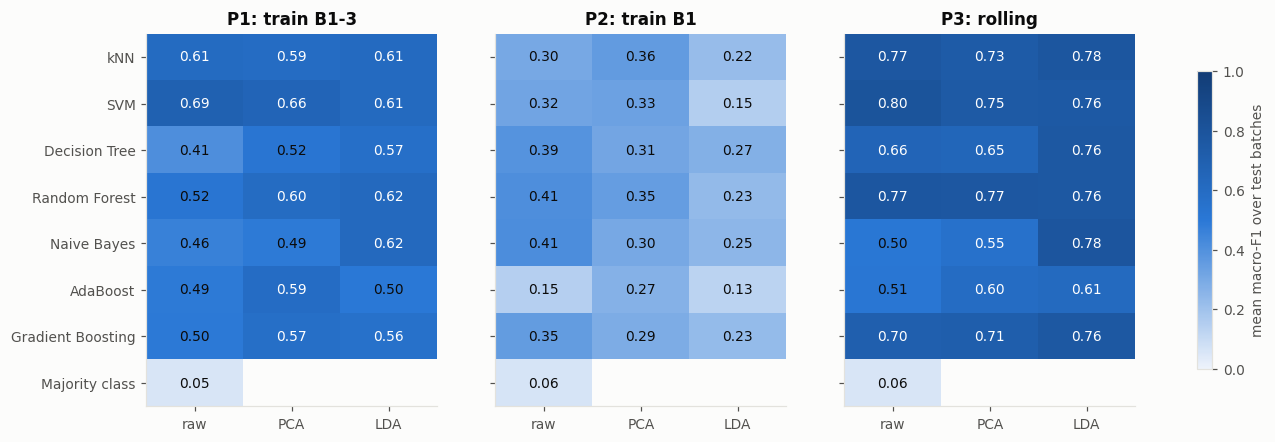

mean_accuracy  mean_macro_f1  weighted_accuracy  \
model             variant                                                    
kNN               raw              0.615          0.609              0.581   
                  PCA              0.601          0.594              0.571   
                  LDA              0.640          0.610              0.559   
SVM               raw              0.705          0.690              0.608   
                  PCA              0.666          0.660              0.563   
                  LDA              0.666          0.614              0.602   
Decision Tree     raw              0.465          0.408              0.412   
                  PCA              0.573          0.519              0.473   
                  LDA              0.593          0.567              0.509   
Random Forest     raw              0.573          0.518              0.514   
                  PCA              0.646          0.599              0.572   
                  LDA              0.647          0.625              0.572   
Naive Bayes       raw              0.506          0.461              0.447   
                  PCA              0.563          0.490              0.435   
                  LDA              0.632          0.621              0.614   
AdaBoost          raw              0.516          0.488              0.378   
                  PCA              0.657          0.594              0.589   
                  LDA              0.492          0.497              0.394   
Gradient Boosting raw              0.531          0.495              0.475   
                  PCA              0.624          0.570              0.551   
                  LDA              0.567          0.556              0.477   
Majority class    raw              0.184          0.055              0.188   

                           weighted_macro_f1  min_macro_f1  
model             variant                                   
kNN               raw                  0.558         0.464  
                  PCA                  0.547         0.441  
                  LDA                  0.532         0.349  
SVM               raw                  0.579         0.431  
                  PCA                  0.552         0.450  
                  LDA                  0.556         0.404  
Decision Tree     raw                  0.354         0.173  
                  PCA                  0.416         0.343  
                  LDA                  0.491         0.342  
Random Forest     raw                  0.467         0.175  
                  PCA                  0.514         0.393  
                  LDA                  0.551         0.284  
Naive Bayes       raw                  0.412         0.099  
                  PCA                  0.385         0.197  
                  LDA                  0.597         0.264  
AdaBoost          raw                  0.332         0.250  
                  PCA                  0.532         0.458  
                  LDA                  0.386         0.254  
Gradient Boosting raw                  0.437         0.218  
                  PCA                  0.499         0.336  
                  LDA                  0.466         0.272  
Majority class    raw                  0.053         0.031

In [3]:
order = list(models) + ["Majority class"]
def table(proto, col="mean_macro_f1"):
    t = summ[summ.protocol == proto].pivot(index="model", columns="variant", values=col).reindex(order)
    return t[["raw", "PCA", "LDA"]]

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.4), sharey=True)
for ax, proto in zip(axes, ["P1", "P2", "P3"]):
    t = table(proto); im = ax.imshow(t.values, cmap=SEQ, vmin=0, vmax=1, aspect="auto"); ax.grid(False)
    ax.set_xticks(range(3)); ax.set_xticklabels(t.columns); ax.set_yticks(range(len(t))); ax.set_yticklabels(t.index)
    for i in range(t.shape[0]):
        for j in range(3):
            v = t.values[i, j]
            if not np.isnan(v): ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=9, color="white" if v > 0.55 else INK)
    ax.set_title({"P1": "P1: train B1-3", "P2": "P2: train B1", "P3": "P3: rolling"}[proto])
fig.colorbar(im, ax=axes, shrink=0.8, label="mean macro-F1 over test batches")
fig.savefig(FIG / "14_baselines_heatmap.png"); plt.show()

p1 = summ[summ.protocol == "P1"].set_index(["model", "variant"])
display(p1[["mean_accuracy", "mean_macro_f1", "weighted_accuracy", "weighted_macro_f1", "min_macro_f1"]].reindex(
        [(m, v) for m in order for v in ["raw", "PCA", "LDA"] if (m, v) in p1.index]).round(3))

## 3. Ranking and per-batch behaviour (raw features)

`mean` treats every test batch equally; `weighted` treats every sample equally (batches 6, 7 and 10 dominate).
The ranking below is **descriptive**: choosing the final model by looking at test batches would be tuning on the test set, so the
final model will be chosen with validation inside the training batches.

In [4]:
for proto in ["P1", "P2", "P3"]:
    s = summ[(summ.protocol == proto) & (summ.model != "Majority class")].sort_values("mean_macro_f1", ascending=False)
    print(f"\n{proto}: top 5 (model, pipeline) by mean macro-F1")
    display(s[["model", "variant", "mean_accuracy", "mean_macro_f1", "weighted_macro_f1"]].head(5).round(3).reset_index(drop=True))


P1: top 5 (model, pipeline) by mean macro-F1


,model,variant,mean_accuracy,mean_macro_f1,weighted_macro_f1
0,SVM,raw,0.705,0.690,0.579
1,SVM,PCA,0.666,0.660,0.552
2,Random Forest,LDA,0.647,0.625,0.551
3,Naive Bayes,LDA,0.632,0.621,0.597
4,SVM,LDA,0.666,0.614,0.556



P2: top 5 (model, pipeline) by mean macro-F1


,model,variant,mean_accuracy,mean_macro_f1,weighted_macro_f1
0,Naive Bayes,raw,0.484,0.413,0.380
1,Random Forest,raw,0.487,0.410,0.376
2,Decision Tree,raw,0.435,0.387,0.340
3,kNN,PCA,0.426,0.358,0.368
4,Gradient Boosting,raw,0.458,0.355,0.355



P3: top 5 (model, pipeline) by mean macro-F1


,model,variant,mean_accuracy,mean_macro_f1,weighted_macro_f1
0,SVM,raw,0.824,0.797,0.750
1,Naive Bayes,LDA,0.786,0.783,0.773
2,kNN,LDA,0.796,0.779,0.736
3,Random Forest,raw,0.812,0.774,0.702
4,Random Forest,PCA,0.797,0.769,0.716


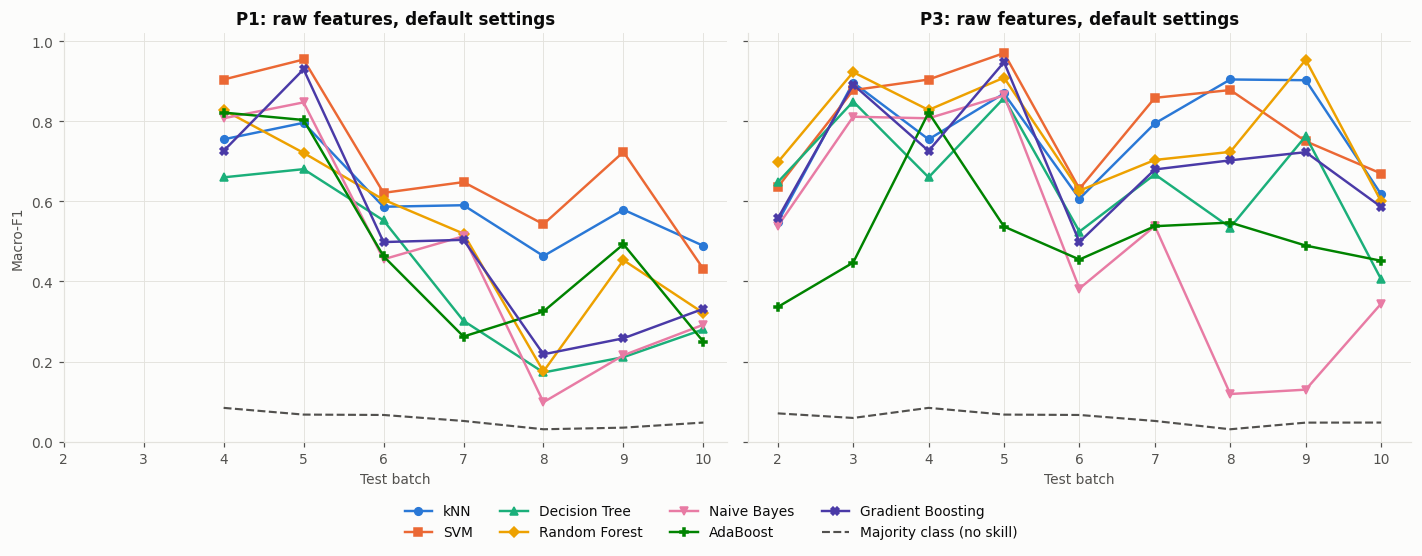

In [5]:
colors = {m: SERIES[i] for i, m in enumerate(models)}; marks = {m: MARKERS[i] for i, m in enumerate(models)}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharey=True)
for ax, proto in zip(axes, ["P1", "P3"]):
    for m in models:
        d = res_all[(res_all.model == m) & (res_all.protocol == proto) & (res_all.variant == "raw")]
        ax.plot(d.test_batch, d.macro_f1, color=colors[m], marker=marks[m], ms=5, lw=1.6, label=m)
    d = res_all[(res_all.model == "Majority class") & (res_all.protocol == proto)]
    ax.plot(d.test_batch, d.macro_f1, color=INK2, ls="--", lw=1.4, label="Majority class (no skill)")
    ax.set_title(f"{proto}: raw features, default settings"); ax.set_xlabel("Test batch"); ax.set_xticks(range(2, 11)); ax.set_ylim(0, 1.02)
axes[0].set_ylabel("Macro-F1")
h, l = axes[0].get_legend_handles_labels(); fig.legend(h, l, loc="lower center", ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.1))
fig.tight_layout(); fig.savefig(FIG / "15_baselines_per_batch.png"); plt.show()

## 4. Which models degrade least as the data gets older? (P1, raw features)

For each model we compare its macro-F1 on the **nearest** unseen batches (4-5, closest in time to training) with the **farthest** ones
(8-10). A short line = the model keeps its skill; a long line = it is sensitive to drift.

,near (B4-5),far (B8-10),drop
model,,,
Majority class,0.076,0.038,0.038
Naive Bayes,0.828,0.202,0.625
Decision Tree,0.670,0.221,0.449
Gradient Boosting,0.828,0.269,0.559
Random Forest,0.775,0.317,0.458
AdaBoost,0.813,0.356,0.457
kNN,0.776,0.511,0.265
SVM,0.930,0.566,0.364


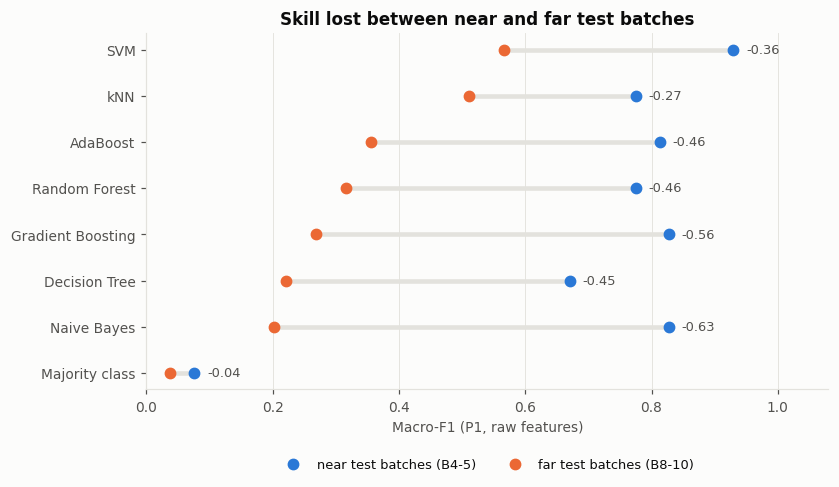

In [6]:
r = res_all[(res_all.protocol == "P1") & (res_all.variant == "raw")]
near = r[r.test_batch.isin([4, 5])].groupby("model").macro_f1.mean()
far = r[r.test_batch.isin([8, 9, 10])].groupby("model").macro_f1.mean()
nf = pd.DataFrame({"near (B4-5)": near, "far (B8-10)": far}); nf["drop"] = nf["near (B4-5)"] - nf["far (B8-10)"]
nf = nf.sort_values("far (B8-10)"); nf.to_csv(RES / "04_near_vs_far_P1.csv"); display(nf.round(3))

fig, ax = plt.subplots(figsize=(8, 4.2))
for i, (m, row) in enumerate(nf.iterrows()):
    ax.plot([row["far (B8-10)"], row["near (B4-5)"]], [i, i], color=GRID, lw=3, zorder=1)
    ax.scatter(row["near (B4-5)"], i, color=SERIES[0], s=45, zorder=2); ax.scatter(row["far (B8-10)"], i, color=SERIES[1], s=45, zorder=2)
    ax.text(max(row["near (B4-5)"], row["far (B8-10)"]) + 0.02, i, f"-{row['drop']:.2f}", va="center", fontsize=8.5, color=INK2)
ax.set_yticks(range(len(nf))); ax.set_yticklabels(nf.index); ax.set_xlim(0, 1.08); ax.set_xlabel("Macro-F1 (P1, raw features)"); ax.grid(axis="y", visible=False)
ax.scatter([], [], color=SERIES[0], s=45, label="near test batches (B4-5)"); ax.scatter([], [], color=SERIES[1], s=45, label="far test batches (B8-10)")
ax.legend(frameon=False, fontsize=8.5, loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=2); ax.set_title("Skill lost between near and far test batches")
fig.savefig(FIG / "16_near_vs_far.png"); plt.show()

## 5. Key takeaways

All models use default settings (untuned). Numbers are the mean over test batches; the best pipeline per model is shown for P1 (train B1-3).

| Model | Best P1 pipeline | Accuracy / macro-F1 | Raw (scaling only) macro-F1 |
|---|---|---|---|
| **SVM** | raw | **70.5% / 69.0%** | 69.0% |
| Random Forest | LDA | 64.7% / 62.5% | 51.8% |
| Naive Bayes | LDA | 63.2% / 62.1% | 46.1% |
| kNN | LDA (raw is equal) | 64.0% / 61.0% | 60.9% |
| AdaBoost | PCA | 65.7% / 59.4% | 48.8% |
| Gradient Boosting | PCA | 62.4% / 57.0% | 49.5% |
| Decision Tree | LDA | 59.3% / 56.7% | 40.8% |
| *Majority class (no skill)* | - | *18.4% / 5.5%* | 5.5% |

1. **SVM is the strongest baseline under the headline protocol.** P1: 69.0% macro-F1 (70.5% accuracy) with plain scaling. Under rolling retraining (P3) it is again first: 79.7% macro-F1 (82.4% accuracy), ahead of Random Forest (77.4%) and kNN (76.6%). Every model clears the no-skill floor by a wide margin (5.5% macro-F1, 18.4% accuracy under P1).
2. **The ranking depends on the protocol.** When training on batch 1 only (P2), all models are weak (best: Naive Bayes 41.3% and Random Forest 41.0% macro-F1, raw features), and SVM (31.6%) and kNN (30.3%) fall *behind* Naive Bayes, Random Forest, Decision Tree and Gradient Boosting. So no single "best model" claim is safe without more evidence; significance tests are planned for the final phase.
3. **Distance-based models hold up best as data gets older.** On raw features under P1, macro-F1 on the nearest unseen batches (4-5) vs the farthest (8-10): SVM 93.0% -> 56.6%, kNN 77.6% -> 51.1%, but AdaBoost 81.3% -> 35.6%, Random Forest 77.5% -> 31.7%, Gradient Boosting 82.8% -> 26.9%, Decision Tree 67.0% -> 22.1% and **Naive Bayes 82.8% -> 20.2%** (a 63-point drop). A model that is excellent on near-term data can be the worst on distant data. A plausible but untested explanation: trees split on hard thresholds of individual raw features and Naive Bayes assumes fixed per-feature distributions, both of which drift breaks.
4. **PCA and LDA help most models, but not the best ones, and the effect depends on the protocol.** Under P1, 5 of the 7 models improve with PCA or LDA (Naive Bayes +16.0 points with LDA, Decision Tree +15.9, Random Forest +10.7, AdaBoost +10.6 with PCA, Gradient Boosting +7.5 with PCA), whereas SVM loses (-3.0 PCA, -7.6 LDA) and kNN is unchanged. This refines the Step 3 finding (which only covered SVM and kNN). Under P2 plain scaling is best for 4 of the 7 models, and under P3 LDA is best for 5 of 7 (e.g. Naive Bayes 50.4% -> 78.3%), though SVM (79.7%, raw) and Random Forest (77.4%, raw) remain on top.
5. **With regular retraining, differences between models shrink.** In P3 with LDA, five models land within 76.3-78.3% macro-F1 (Naive Bayes, kNN, Decision Tree, Gradient Boosting, Random Forest). The choice of model matters much less than how recent the training data is.
6. **Caveats for the review.** These are untuned defaults on a handful of test batches (some tiny); differences of a few points are within noise. The ranking above is descriptive: picking the final model by test-batch scores would be tuning on the test set, so the final model will be chosen with validation inside the training batches.